# Build quarterly macro panel

This notebook is the only place where raw FRED and EBP observations are aggregated, aligned, transformed, and exported for modelling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


CONFIG_PATH = Path('../data/raw/fred_series_config.yaml')
FRED_RAW_DIR = Path("../data/raw")
EBP_PATH = Path('../data/raw/ebp.csv')
OUTPUT_PATH = Path('../data/macro_panel_quarterly.csv')

In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as file:
    SERIES_CONFIG = yaml.safe_load(file)["series"]

config = pd.DataFrame(SERIES_CONFIG)
config

,name,fred_id,category,native_frequency,quarterly_aggregation,transformation,description
0,real_gdp_growth,A191RL1Q225SBEA,real_activity,quarterly,None,level,"Real GDP growth, annualised percent"
1,unemployment_rate,UNRATE,real_activity,monthly,average,level,NaN
2,industrial_production,INDPRO,real_activity,monthly,average,log_diff,NaN
3,real_disposable_personal_income,DSPIC96,real_activity,monthly,average,log_diff,NaN
4,cpi,CPIAUCSL,prices,monthly,average,log_diff,NaN
5,house_price_index,USSTHPI,asset_prices_housing,quarterly,None,log_diff,NaN
6,federal_funds_rate,FEDFUNDS,monetary_interest_rates,monthly,average,level,NaN
7,treasury_10y_2y_spread,T10Y2Y,monetary_interest_rates,daily,average,level,NaN
8,vix,VIXCLS,financial_conditions_credit_risk,daily,average,level,NaN
9,corporate_bond_spread,BAA10Y,financial_conditions_credit_risk,daily,average,level,NaN


In [3]:
def validate_raw_dates(df: pd.DataFrame, value_col: str, label: str) -> None:
    """Check raw files before any quarterly modelling transformations."""
    if "DATE" not in df.columns:
        raise ValueError(f"{label} is missing a DATE column")
    if value_col not in df.columns:
        raise ValueError(f"{label} is missing value column {value_col}")

    if df["DATE"].isna().any():
        raise ValueError(f"{label} has missing or unparseable dates")
    duplicate_count = int(df["DATE"].duplicated().sum())
    if duplicate_count:
        raise ValueError(f"{label} has {duplicate_count} duplicate dates")

    ordered = df.sort_values("DATE")
    if not ordered["DATE"].is_monotonic_increasing:
        raise ValueError(f"{label} dates could not be sorted cleanly")


def load_raw_series(path: Path, value_col: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col].replace(".", pd.NA), errors="coerce")
    validate_raw_dates(df, value_col, label)
    return df.sort_values("DATE").reset_index(drop=True)


def aggregate_to_quarter(df: pd.DataFrame, value_col: str, aggregation, label: str) -> pd.Series:
    """Convert raw observations to quarterly values using the configured aggregation."""
    quarterly = df.copy()
    quarterly["quarter"] = quarterly["DATE"].dt.to_period("Q")

    if aggregation is None or pd.isna(aggregation):
        duplicate_quarters = int(quarterly["quarter"].duplicated().sum())
        if duplicate_quarters:
            raise ValueError(f"{label} has {duplicate_quarters} duplicate quarterly observations")
        result = quarterly.set_index("quarter")[value_col]
    elif aggregation == "average":
        result = quarterly.groupby("quarter")[value_col].mean()
    elif aggregation == "sum":
        result = quarterly.groupby("quarter")[value_col].sum(min_count=1)
    elif aggregation in {"last", "end_of_period"}:
        result = quarterly.sort_values("DATE").groupby("quarter")[value_col].last()
    else:
        raise ValueError(f"Unsupported quarterly aggregation for {label}: {aggregation}")

    result.index = result.index.to_timestamp(how="end").normalize()
    result.name = label
    return result.sort_index()


def apply_transformation(series: pd.Series, transformation: str, label: str) -> pd.Series:
    """Apply modelling transformations after quarterly aggregation/alignment."""
    if transformation == "level":
        transformed = series.copy()
    elif transformation == "log_diff":
        non_positive = int((series <= 0).sum())
        if non_positive:
            raise ValueError(f"{label} has {non_positive} non-positive values before log_diff")
        transformed = 100 * np.log(series).diff()
    elif transformation in {"annualised_percent_level", "annualized_percent_level"}:
        transformed = series.copy()
    else:
        raise ValueError(f"Unsupported transformation for {label}: {transformation}")

    transformed.name = label
    return transformed

In [4]:
quarterly_raw = {}
transformed_series = {}
validation_rows = []

for spec in SERIES_CONFIG:
    name = spec["name"]
    fred_id = spec["fred_id"]
    path = FRED_RAW_DIR / f"{fred_id}.csv"
    raw = load_raw_series(path, fred_id, name)

    quarterly = aggregate_to_quarter(raw, fred_id, spec["quarterly_aggregation"], name)
    transformed = apply_transformation(quarterly, spec["transformation"], name)

    quarterly_raw[name] = quarterly
    transformed_series[name] = transformed
    validation_rows.append(
        {
            "series": name,
            "raw_start": raw["DATE"].min(),
            "raw_end": raw["DATE"].max(),
            "quarterly_start": quarterly.index.min(),
            "quarterly_end": quarterly.index.max(),
            "raw_missing_values": int(raw[fred_id].isna().sum()),
            "quarterly_missing_values": int(quarterly.isna().sum()),
            "transformation_induced_nans": int(transformed.isna().sum() - quarterly.isna().sum()),
        }
    )

validation = pd.DataFrame(validation_rows)
validation

,series,raw_start,raw_end,quarterly_start,quarterly_end,raw_missing_values,quarterly_missing_values,transformation_induced_nans
0,real_gdp_growth,1947-04-01,2026-01-01,1947-06-30,2026-03-31,0,0,0
1,unemployment_rate,1948-01-01,2026-05-01,1948-03-31,2026-06-30,1,0,0
2,industrial_production,1919-01-01,2026-04-01,1919-03-31,2026-06-30,0,0,1
3,real_disposable_personal_income,1959-01-01,2026-04-01,1959-03-31,2026-06-30,0,0,1
4,cpi,1947-01-01,2026-04-01,1947-03-31,2026-06-30,1,0,1
5,house_price_index,1975-01-01,2026-01-01,1975-03-31,2026-03-31,0,0,1
6,federal_funds_rate,1954-07-01,2026-05-01,1954-09-30,2026-06-30,0,0,0
7,treasury_10y_2y_spread,1976-06-01,2026-06-05,1976-06-30,2026-06-30,549,0,0
8,vix,1990-01-02,2026-06-04,1990-03-31,2026-06-30,302,0,0
9,corporate_bond_spread,1986-01-02,2026-06-04,1986-03-31,2026-06-30,440,0,0


In [5]:
# EBP is not a FRED series, so it is loaded separately and processed here.
EBP_AGGREGATION = "average"
EBP_TRANSFORMATION = "level"

ebp_raw = load_raw_series(EBP_PATH, "EBP", "excess_bond_premium")
ebp_quarterly = aggregate_to_quarter(ebp_raw, "EBP", EBP_AGGREGATION, "excess_bond_premium")
transformed_series["excess_bond_premium"] = apply_transformation(
    ebp_quarterly,
    EBP_TRANSFORMATION,
    "excess_bond_premium",
)

pd.DataFrame(
    [
        {
            "series": "excess_bond_premium",
            "raw_start": ebp_raw["DATE"].min(),
            "raw_end": ebp_raw["DATE"].max(),
            "quarterly_start": ebp_quarterly.index.min(),
            "quarterly_end": ebp_quarterly.index.max(),
            "raw_missing_values": int(ebp_raw["EBP"].isna().sum()),
            "quarterly_missing_values": int(ebp_quarterly.isna().sum()),
            "transformation_induced_nans": int(transformed_series["excess_bond_premium"].isna().sum() - ebp_quarterly.isna().sum()),
        }
    ]
)

,series,raw_start,raw_end,quarterly_start,quarterly_end,raw_missing_values,quarterly_missing_values,transformation_induced_nans
0,excess_bond_premium,1973-01-01,2026-05-01,1973-03-31,2026-06-30,0,0,0


In [6]:
panel_with_nans = pd.concat(transformed_series.values(), axis=1).sort_index()
panel_with_nans.index.name = "DATE"

# Missing-quarter check after alignment. This catches gaps in the quarterly panel index.
full_quarter_index = pd.date_range(
    panel_with_nans.index.min(),
    panel_with_nans.index.max(),
    freq="QE-DEC",
)
missing_quarter_dates = full_quarter_index.difference(panel_with_nans.index)
if len(missing_quarter_dates):
    raise ValueError(f"Quarterly panel has missing dates: {missing_quarter_dates.tolist()}")

# Transformation-induced NaNs are expected for the first observation of log differences.
# Remaining NaNs show non-overlap across series vintages or missing raw observations.
nan_report = panel_with_nans.isna().sum().rename("nan_count").to_frame()
nan_report["first_valid_date"] = panel_with_nans.apply(lambda column: column.first_valid_index())
nan_report["last_valid_date"] = panel_with_nans.apply(lambda column: column.last_valid_index())
nan_report

,nan_count,first_valid_date,last_valid_date
real_gdp_growth,114,1947-06-30,2026-03-31
unemployment_rate,116,1948-03-31,2026-06-30
industrial_production,1,1919-06-30,2026-06-30
real_disposable_personal_income,161,1959-06-30,2026-06-30
cpi,113,1947-06-30,2026-06-30
house_price_index,226,1975-06-30,2026-03-31
federal_funds_rate,142,1954-09-30,2026-06-30
treasury_10y_2y_spread,229,1976-06-30,2026-06-30
vix,284,1990-03-31,2026-06-30
corporate_bond_spread,268,1986-03-31,2026-06-30


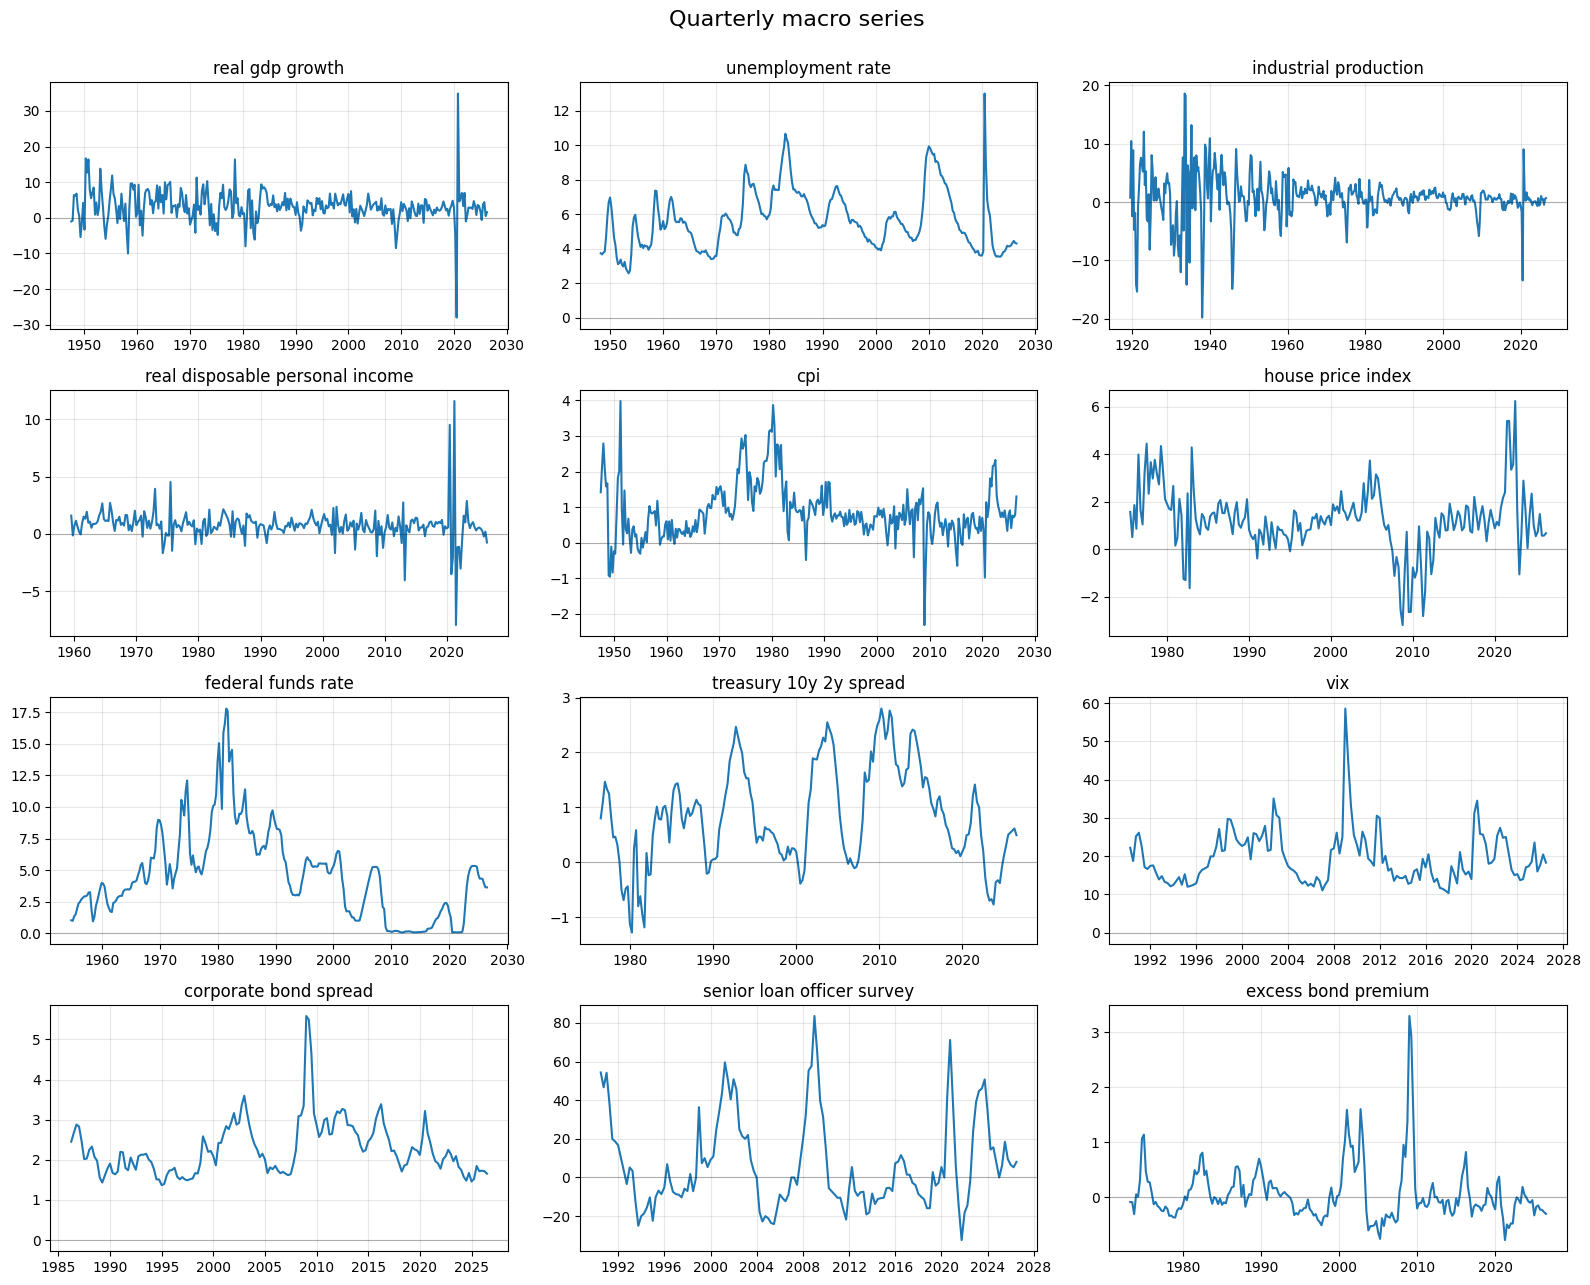

In [8]:
n_series = panel_with_nans.shape[1]
n_cols = 3
n_rows = int(np.ceil(n_series / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows), sharex=False)
axes = axes.ravel()

for ax, column in zip(axes, panel_with_nans.columns):
    series = panel_with_nans[column].dropna()
    ax.plot(series.index, series, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.25)
    ax.set_title(column.replace("_", " "))
    ax.grid(True, alpha=0.3)

for ax in axes[n_series:]:
    ax.remove()

fig.suptitle("Quarterly macro series", y=1.0, fontsize=16)
fig.tight_layout()
fig.savefig('../figures/macro_covariates_panel.png')
plt.show()

In [9]:
macro_panel = panel_with_nans.dropna().reset_index()

if macro_panel.empty:
    raise ValueError("No complete quarterly observations remain after alignment")
if macro_panel["DATE"].duplicated().any():
    raise ValueError("Final macro panel contains duplicate dates")

In [10]:

macro_panel.to_csv(OUTPUT_PATH, index=False)

print(f"Saved {len(macro_panel)} quarterly rows to {OUTPUT_PATH}")
macro_panel.head()

Saved 144 quarterly rows to ../processed/macro_panel_quarterly.csv


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium
0,1990-06-30,1.5,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.4,0.146990
1,1990-09-30,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.7,-0.047302
2,1990-12-31,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.2,0.266956
3,1991-03-31,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.6,0.305454
4,1991-06-30,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.0,0.162705
